In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras

print("TensorFlow:", tf.__version__)
print("Working directory:", os.getcwd())


TensorFlow: 2.21.0
Working directory: d:\Practice Projects\Disease Detection\notebooks


In [2]:
# STEP 2 — Find project root
candidates = [
    Path.cwd(),
    Path.cwd().parent,
    Path(r"D:/Practice Projects/Disease Detection")
]

PROJECT_ROOT = next((p for p in candidates if (p / "model").exists()), None)

if PROJECT_ROOT is None:
    raise FileNotFoundError("Disease Detection project root was not found.")

print("PROJECT_ROOT:", PROJECT_ROOT)


PROJECT_ROOT: d:\Practice Projects\Disease Detection


In [3]:
# STEP 3 — Find fine-tuned model
MODEL_CANDIDATES = [
    PROJECT_ROOT / "model" / "efficientnetv2_finetuned_best.keras",
    PROJECT_ROOT / "model" / "efficientnetv2" / "efficientnetv2_finetuned_best.keras",
    PROJECT_ROOT / "model" / "efficientnetv2_finetuned" / "efficientnetv2_finetuned_best.keras",
]

MODEL_PATH = next((p for p in MODEL_CANDIDATES if p.exists()), None)

if MODEL_PATH is None:
    matches = list((PROJECT_ROOT / "model").rglob("*finetuned*best*.keras"))
    if matches:
        MODEL_PATH = matches[0]

if MODEL_PATH is None:
    raise FileNotFoundError("No fine-tuned .keras model found in the model folder.")

print("MODEL_PATH:", MODEL_PATH)


MODEL_PATH: d:\Practice Projects\Disease Detection\model\efficientnetv2_finetuned_best.keras


In [4]:
# STEP 4 — Load model
final_model = keras.models.load_model(MODEL_PATH)

print("Model loaded successfully.")
print("Input shape:", final_model.input_shape)
print("Output shape:", final_model.output_shape)


Model loaded successfully.
Input shape: (None, 224, 224, 3)
Output shape: (None, 5)


In [5]:
# STEP 5 — Basic settings
IMG_SIZE = (224, 224)
NUM_CLASSES = int(final_model.output_shape[-1])

# If your project has actual disease names, replace these names only.
class_names = [f"Class {i}" for i in range(NUM_CLASSES)]

print("Classes:", class_names)


Classes: ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4']


In [6]:
# STEP 6 — Find images
search_roots = [
    PROJECT_ROOT / "preprocessing",
    PROJECT_ROOT / "dataset",
    PROJECT_ROOT / "data"
]

extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
image_files = []

for root in search_roots:
    if root.exists():
        image_files.extend(
            p for p in root.rglob("*")
            if p.is_file() and p.suffix.lower() in extensions
        )

image_files = sorted(set(image_files))

if not image_files:
    raise FileNotFoundError(
        "No images found in preprocessing/dataset/data folders."
    )

print("Total images found:", len(image_files))
print("First image:", image_files[0])


Total images found: 1800
First image: d:\Practice Projects\Disease Detection\dataset\Messidor-2+EyePac_Balanced\0\20051020_43808_0100_PP.png


In [7]:
# STEP 7 — Select image
IMAGE_INDEX = 0
image_path = image_files[IMAGE_INDEX]

print("Selected image:", image_path)


Selected image: d:\Practice Projects\Disease Detection\dataset\Messidor-2+EyePac_Balanced\0\20051020_43808_0100_PP.png


In [9]:
# STEP 8 — Load image
def load_image(path):
    original = Image.open(path).convert("RGB")
    resized = original.resize(IMG_SIZE)
    arr = np.asarray(resized, dtype=np.float32)

    # EfficientNetV2 include_preprocessing=True:
    # keep pixels in 0–255 range.
    batch = np.expand_dims(arr, axis=0)
    return original, batch

original_image, input_tensor = load_image(image_path)

print("Input shape:", input_tensor.shape)
print("Pixel range:", input_tensor.min(), "to", input_tensor.max())


Input shape: (1, 224, 224, 3)
Pixel range: 0.0 to 255.0


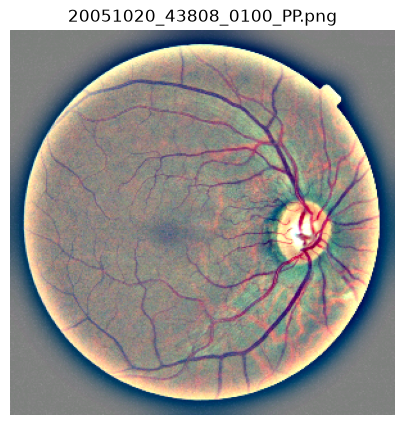

In [10]:
# STEP 9 — Display image
plt.figure(figsize=(5,5))
plt.imshow(original_image)
plt.title(image_path.name)
plt.axis("off")
plt.show()


In [11]:
# STEP 10 — Prediction
pred_probs = final_model.predict(input_tensor, verbose=0)[0]
predicted_class = int(np.argmax(pred_probs))
confidence = float(pred_probs[predicted_class])

print("Predicted class:", predicted_class)
print("Confidence:", f"{confidence*100:.2f}%")
print("Predicted label:", class_names[predicted_class])


Predicted class: 2
Confidence: 37.48%
Predicted label: Class 2


In [13]:
# STEP 11 — Find suitable 4-D feature layer
target_layer = None

for layer in reversed(final_model.layers):
    try:
        if len(layer.output.shape) == 4:
            target_layer = layer
            break
    except Exception:
        pass

if target_layer is None:
    raise ValueError("No suitable 4-D feature layer found.")

print("Grad-CAM target layer:", target_layer.name)
print("Output shape:", target_layer.output.shape)


Grad-CAM target layer: efficientnetv2-b0
Output shape: (None, 7, 7, 1280)


In [18]:
# STEP 12 — Create Grad-CAM connection (Corrected for nested EfficientNetV2)

# Get the EfficientNetV2 backbone
backbone = final_model.get_layer("efficientnetv2-b0")

# Get classifier layers from the trained model
gap_layer = final_model.get_layer("global_average_pooling")
bn_layer = final_model.get_layer("classifier_bn")
dropout_layer = final_model.get_layer("classifier_dropout")
output_layer = final_model.get_layer("disease_output")

print("Backbone:", backbone.name)
print("Backbone output:", backbone.output_shape)

# Grad-CAM forward pass
@tf.function
def gradcam_forward(image_tensor, class_index):

    with tf.GradientTape() as tape:

        # Apply the same augmentation layer used during training
        x = final_model.get_layer("augmentation")(image_tensor, training=False)

        # EfficientNetV2 feature extraction
        feature_maps = backbone(x, training=False)

        # Tell GradientTape to watch the feature maps
        tape.watch(feature_maps)

        # Original classifier
        x = gap_layer(feature_maps)
        x = bn_layer(x, training=False)
        x = dropout_layer(x, training=False)
        predictions = output_layer(x)

        class_score = predictions[:, class_index]

    gradients = tape.gradient(
        class_score,
        feature_maps
    )

    return feature_maps, predictions, gradients

print("Grad-CAM forward function created successfully.")

Backbone: efficientnetv2-b0
Backbone output: (None, 7, 7, 1280)
Grad-CAM forward function created successfully.


In [21]:
# STEP 13 — Generate Grad-CAM heatmap (Corrected)

import numpy as np
import tensorflow as tf

def make_gradcam_heatmap(image_tensor, class_index):

    with tf.GradientTape() as tape:

        # Correct augmentation layer name
        augmentation_layer = final_model.get_layer("fundus_augmentation")

        x = augmentation_layer(
            image_tensor,
            training=False
        )

        # EfficientNetV2 backbone
        feature_maps = backbone(
            x,
            training=False
        )

        tape.watch(feature_maps)

        # Classifier
        x = gap_layer(feature_maps)
        x = bn_layer(x, training=False)
        x = dropout_layer(x, training=False)
        predictions = output_layer(x)

        class_score = predictions[:, class_index]

    # Calculate gradients
    gradients = tape.gradient(
        class_score,
        feature_maps
    )

    # Average gradients
    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(1, 2)
    )

    feature_maps = feature_maps[0]
    pooled_gradients = pooled_gradients[0]

    # Generate weighted feature map
    heatmap = tf.reduce_sum(
        feature_maps * pooled_gradients,
        axis=-1
    )

    # ReLU
    heatmap = tf.maximum(heatmap, 0)

    # Normalize
    max_value = tf.reduce_max(heatmap)

    heatmap = tf.where(
        max_value > 0,
        heatmap / max_value,
        heatmap
    )

    return heatmap.numpy()


# Generate Grad-CAM for predicted class
heatmap = make_gradcam_heatmap(
    input_tensor,
    predicted_class
)

print("Grad-CAM heatmap generated successfully.")
print("Heatmap shape:", heatmap.shape)
print("Heatmap range:", heatmap.min(), "to", heatmap.max())

Grad-CAM heatmap generated successfully.
Heatmap shape: (7, 7)
Heatmap range: 0.0 to 1.0


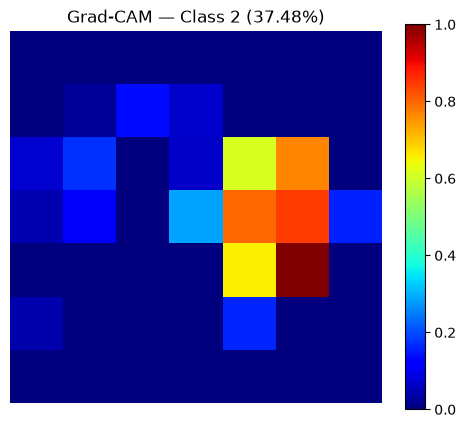

In [22]:
# STEP 14 — Display heatmap
plt.figure(figsize=(6,5))
plt.imshow(heatmap, cmap="jet")
plt.colorbar()
plt.title(
    f"Grad-CAM — {class_names[predicted_class]} "
    f"({confidence*100:.2f}%)"
)
plt.axis("off")
plt.show()


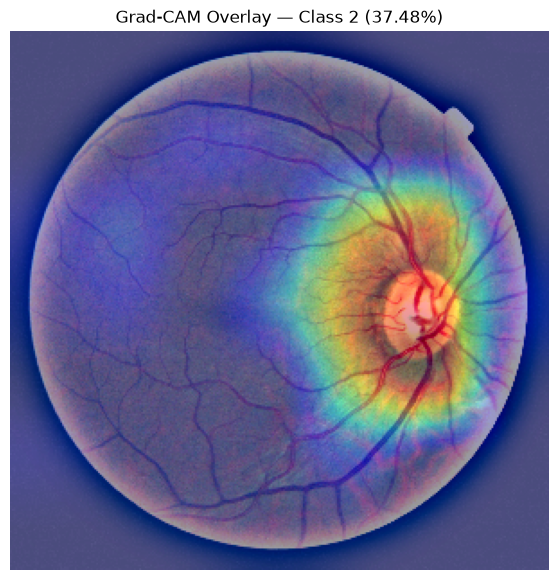

In [23]:
# STEP 15 — Create overlay
def create_overlay(original_img, heatmap, alpha=0.40):
    base = np.asarray(original_img.convert("RGB"), dtype=np.float32)

    heatmap_img = Image.fromarray(
        np.uint8(255 * heatmap)
    ).resize(original_img.size)

    heatmap_arr = np.asarray(heatmap_img, dtype=np.float32)

    cmap = plt.get_cmap("jet")
    colored = cmap(heatmap_arr / 255.0)[..., :3] * 255.0

    overlay = (1-alpha) * base + alpha * colored
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)

    return Image.fromarray(overlay)

overlay_image = create_overlay(original_image, heatmap)

plt.figure(figsize=(7,7))
plt.imshow(overlay_image)
plt.title(
    f"Grad-CAM Overlay — {class_names[predicted_class]} "
    f"({confidence*100:.2f}%)"
)
plt.axis("off")
plt.show()


In [24]:
# STEP 16 — Save Grad-CAM
GRADCAM_DIR = PROJECT_ROOT / "reports" / "gradcam"
GRADCAM_DIR.mkdir(parents=True, exist_ok=True)

output_path = GRADCAM_DIR / f"gradcam_{image_path.stem}.png"
overlay_image.save(output_path)

print("Saved successfully:")
print(output_path)


Saved successfully:
d:\Practice Projects\Disease Detection\reports\gradcam\gradcam_20051020_43808_0100_PP.png


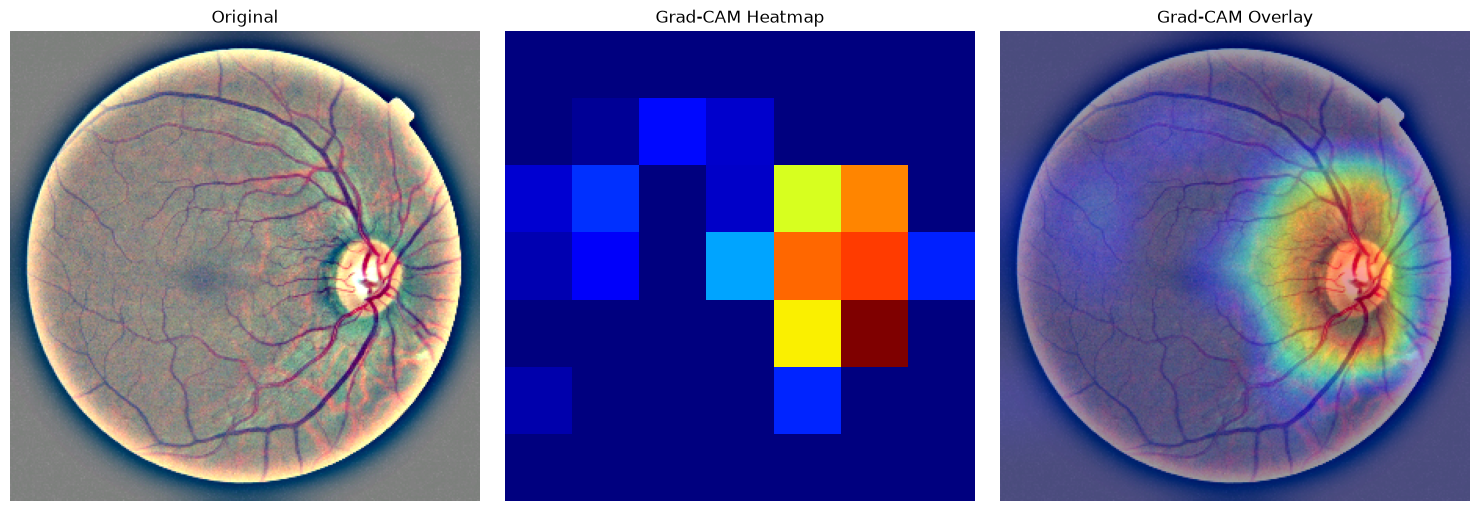

In [25]:
# STEP 17 — Original vs Heatmap vs Overlay
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(original_image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay_image)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()


In [27]:
# STEP 18 — Prediction probabilities
for idx, prob in sorted(
    enumerate(pred_probs),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{class_names[idx]}: {prob*100:.2f}%")


Class 2: 37.48%
Class 1: 31.94%
Class 0: 30.37%
Class 3: 0.13%
Class 4: 0.08%


In [28]:
# STEP 19 — Inspect another image
# Change IMAGE_INDEX below and then rerun Steps 7–18.
# Example:
# IMAGE_INDEX = 1

print("Current IMAGE_INDEX:", IMAGE_INDEX)
print("Change IMAGE_INDEX in Step 7 to inspect another image.")


Current IMAGE_INDEX: 0
Change IMAGE_INDEX in Step 7 to inspect another image.


In [29]:
# STEP 20 — Show saved Grad-CAM files
print("Grad-CAM folder:", GRADCAM_DIR)

for p in sorted(GRADCAM_DIR.glob("*.png")):
    print("-", p.name)


Grad-CAM folder: d:\Practice Projects\Disease Detection\reports\gradcam
- gradcam_20051020_43808_0100_PP.png


In [31]:
# STEP 21 — Generate Grad-CAM for multiple images

from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image

# Find all images from the same dataset used in Step 6
DATASET_DIR = Path(
    r"d:\Practice Projects\Disease Detection\dataset\Messidor-2+EyePac_Balanced"
)

image_extensions = {".png", ".jpg", ".jpeg", ".bmp"}

all_images = sorted(
    [
        p for p in DATASET_DIR.rglob("*")
        if p.is_file() and p.suffix.lower() in image_extensions
    ]
)

print("Total images found:", len(all_images))

# Process first 20 images
NUM_IMAGES = 20
images_to_process = all_images[:NUM_IMAGES]

results = []

for idx, image_path in enumerate(images_to_process):

    # Load image
    image = Image.open(image_path).convert("RGB")
    image = image.resize(IMG_SIZE)

    # Convert to numpy
    image_array = np.array(image).astype("float32")

    # Add batch dimension
    image_tensor = np.expand_dims(image_array, axis=0)

    # Prediction
    predictions = final_model.predict(
        image_tensor,
        verbose=0
    )

    predicted_class = int(np.argmax(predictions[0]))
    confidence = float(np.max(predictions[0]))

    # Grad-CAM
    heatmap = make_gradcam_heatmap(
        image_tensor,
        predicted_class
    )

    results.append({
        "image_path": str(image_path),
        "predicted_class": predicted_class,
        "confidence": confidence,
        "heatmap_shape": str(heatmap.shape)
    })

    print(
        f"{idx + 1}/{len(images_to_process)} | "
        f"Class: {predicted_class} | "
        f"Confidence: {confidence:.2%}"
    )

gradcam_results = pd.DataFrame(results)

print("\nGrad-CAM processing completed.")
print("Total images processed:", len(gradcam_results))

Total images found: 1800
1/20 | Class: 2 | Confidence: 37.48%
2/20 | Class: 2 | Confidence: 49.62%
3/20 | Class: 0 | Confidence: 41.94%
4/20 | Class: 1 | Confidence: 40.80%
5/20 | Class: 1 | Confidence: 43.91%
6/20 | Class: 2 | Confidence: 55.53%
7/20 | Class: 0 | Confidence: 68.59%
8/20 | Class: 0 | Confidence: 55.55%
9/20 | Class: 2 | Confidence: 47.20%
10/20 | Class: 0 | Confidence: 75.35%
11/20 | Class: 0 | Confidence: 65.64%
12/20 | Class: 2 | Confidence: 43.98%
13/20 | Class: 0 | Confidence: 51.22%
14/20 | Class: 0 | Confidence: 39.30%
15/20 | Class: 0 | Confidence: 50.77%
16/20 | Class: 0 | Confidence: 72.59%
17/20 | Class: 0 | Confidence: 64.59%
18/20 | Class: 0 | Confidence: 46.15%
19/20 | Class: 0 | Confidence: 54.70%
20/20 | Class: 0 | Confidence: 62.49%

Grad-CAM processing completed.
Total images processed: 20


In [32]:
# STEP 22 — Save Grad-CAM prediction results

REPORT_DIR = Path(
    r"d:\Practice Projects\Disease Detection\reports\gradcam"
)

REPORT_DIR.mkdir(parents=True, exist_ok=True)

results_csv = REPORT_DIR / "gradcam_multiple_image_results.csv"

gradcam_results.to_csv(
    results_csv,
    index=False
)

print("Grad-CAM results saved successfully:")
print(results_csv)

print("\nResults preview:")
display(gradcam_results.head(10))

Grad-CAM results saved successfully:
d:\Practice Projects\Disease Detection\reports\gradcam\gradcam_multiple_image_results.csv

Results preview:


,image_path,predicted_class,confidence,heatmap_shape
0,d:\Practice Projects\Disease Detection\dataset...,2,0.374845,"(7, 7)"
1,d:\Practice Projects\Disease Detection\dataset...,2,0.496249,"(7, 7)"
2,d:\Practice Projects\Disease Detection\dataset...,0,0.419358,"(7, 7)"
3,d:\Practice Projects\Disease Detection\dataset...,1,0.407959,"(7, 7)"
4,d:\Practice Projects\Disease Detection\dataset...,1,0.439107,"(7, 7)"
5,d:\Practice Projects\Disease Detection\dataset...,2,0.555284,"(7, 7)"
6,d:\Practice Projects\Disease Detection\dataset...,0,0.685902,"(7, 7)"
7,d:\Practice Projects\Disease Detection\dataset...,0,0.555550,"(7, 7)"
8,d:\Practice Projects\Disease Detection\dataset...,2,0.471991,"(7, 7)"
9,d:\Practice Projects\Disease Detection\dataset...,0,0.753515,"(7, 7)"


In [33]:
# STEP 23 — Grad-CAM results summary

print("Total images:", len(gradcam_results))

print("\nPredicted Class Distribution:")
print(
    gradcam_results["predicted_class"]
    .value_counts()
    .sort_index()
)

print("\nAverage Confidence:")
print(
    f"{gradcam_results['confidence'].mean():.2%}"
)

print("\nHighest Confidence:")
print(
    f"{gradcam_results['confidence'].max():.2%}"
)

print("\nLowest Confidence:")
print(
    f"{gradcam_results['confidence'].min():.2%}"
)

Total images: 20

Predicted Class Distribution:
predicted_class
0    13
1     2
2     5
Name: count, dtype: int64

Average Confidence:
53.37%

Highest Confidence:
75.35%

Lowest Confidence:
37.48%


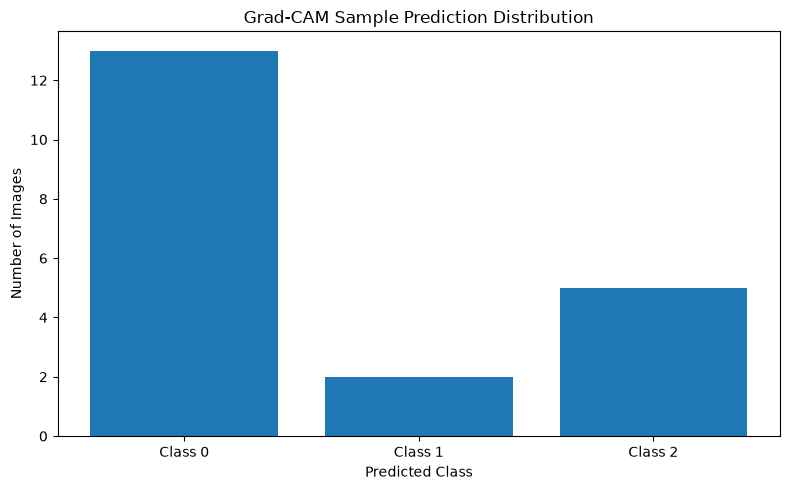

In [34]:
# STEP 24 — Plot prediction distribution

import matplotlib.pyplot as plt

class_counts = (
    gradcam_results["predicted_class"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    [f"Class {i}" for i in class_counts.index],
    class_counts.values
)

plt.xlabel("Predicted Class")
plt.ylabel("Number of Images")
plt.title("Grad-CAM Sample Prediction Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [35]:
# STEP 25 — Confidence Analysis

highest_idx = gradcam_results["confidence"].idxmax()
lowest_idx = gradcam_results["confidence"].idxmin()

highest_result = gradcam_results.loc[highest_idx]
lowest_result = gradcam_results.loc[lowest_idx]

print("Confidence Analysis")
print("=" * 40)

print("\nHighest Confidence:")
print(f"Image: {highest_result['image_path']}")
print(f"Predicted Class: Class {highest_result['predicted_class']}")
print(f"Confidence: {highest_result['confidence']:.2%}")

print("\nLowest Confidence:")
print(f"Image: {lowest_result['image_path']}")
print(f"Predicted Class: Class {lowest_result['predicted_class']}")
print(f"Confidence: {lowest_result['confidence']:.2%}")

Confidence Analysis

Highest Confidence:
Image: d:\Practice Projects\Disease Detection\dataset\Messidor-2+EyePac_Balanced\0\20051020_57967_0100_PP.png
Predicted Class: Class 0
Confidence: 75.35%

Lowest Confidence:
Image: d:\Practice Projects\Disease Detection\dataset\Messidor-2+EyePac_Balanced\0\20051020_43808_0100_PP.png
Predicted Class: Class 2
Confidence: 37.48%


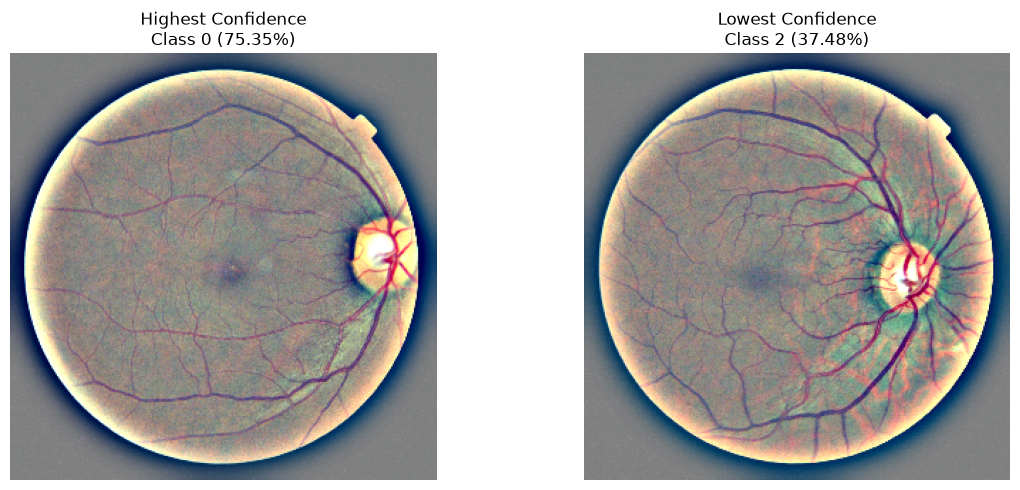

In [36]:
# STEP 26 — Display Highest and Lowest Confidence Images

from PIL import Image
import matplotlib.pyplot as plt

highest_image = Image.open(highest_result["image_path"])
lowest_image = Image.open(lowest_result["image_path"])

plt.figure(figsize=(12, 5))

# Highest confidence
plt.subplot(1, 2, 1)
plt.imshow(highest_image)
plt.axis("off")
plt.title(
    f"Highest Confidence\n"
    f"Class {highest_result['predicted_class']} "
    f"({highest_result['confidence']:.2%})"
)

# Lowest confidence
plt.subplot(1, 2, 2)
plt.imshow(lowest_image)
plt.axis("off")
plt.title(
    f"Lowest Confidence\n"
    f"Class {lowest_result['predicted_class']} "
    f"({lowest_result['confidence']:.2%})"
)

plt.tight_layout()
plt.show()

Total results available: 20

Highest Confidence
Image: d:\Practice Projects\Disease Detection\dataset\Messidor-2+EyePac_Balanced\0\20051020_57967_0100_PP.png
Predicted Class: Class 0
Confidence: 75.35%

Lowest Confidence
Image: d:\Practice Projects\Disease Detection\dataset\Messidor-2+EyePac_Balanced\0\20051020_43808_0100_PP.png
Predicted Class: Class 2
Confidence: 37.48%

Generating Highest Confidence Grad-CAM...


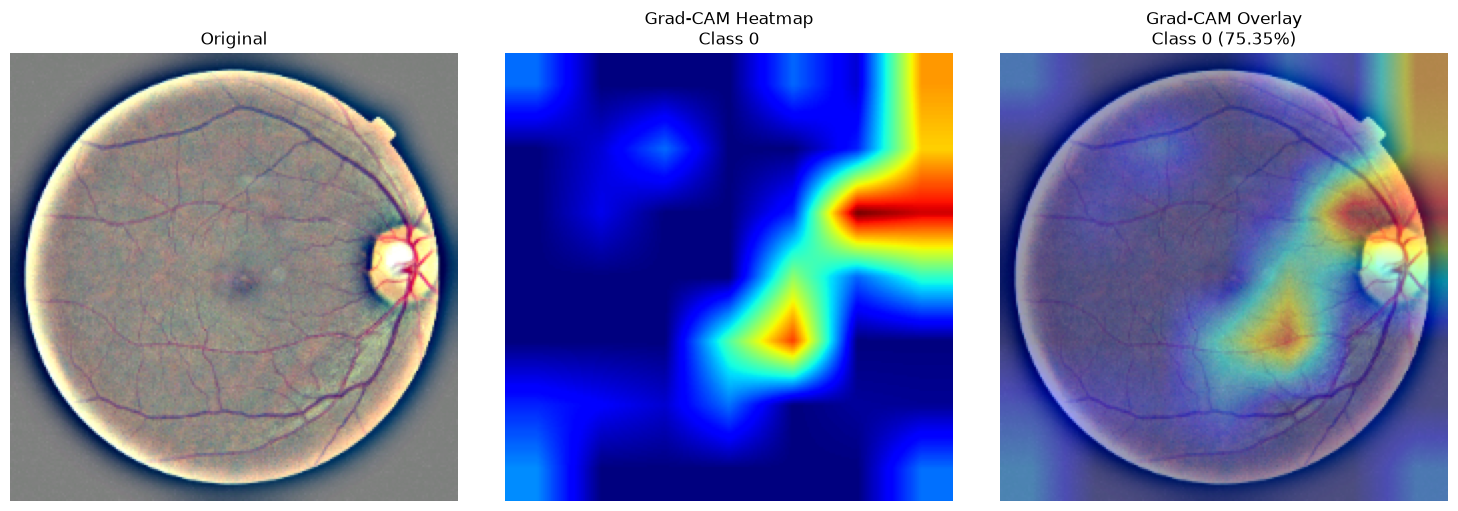

Saved: d:\Practice Projects\Disease Detection\reports\gradcam\gradcam\confidence_analysis\highest_confidence_gradcam.png

Generating Lowest Confidence Grad-CAM...


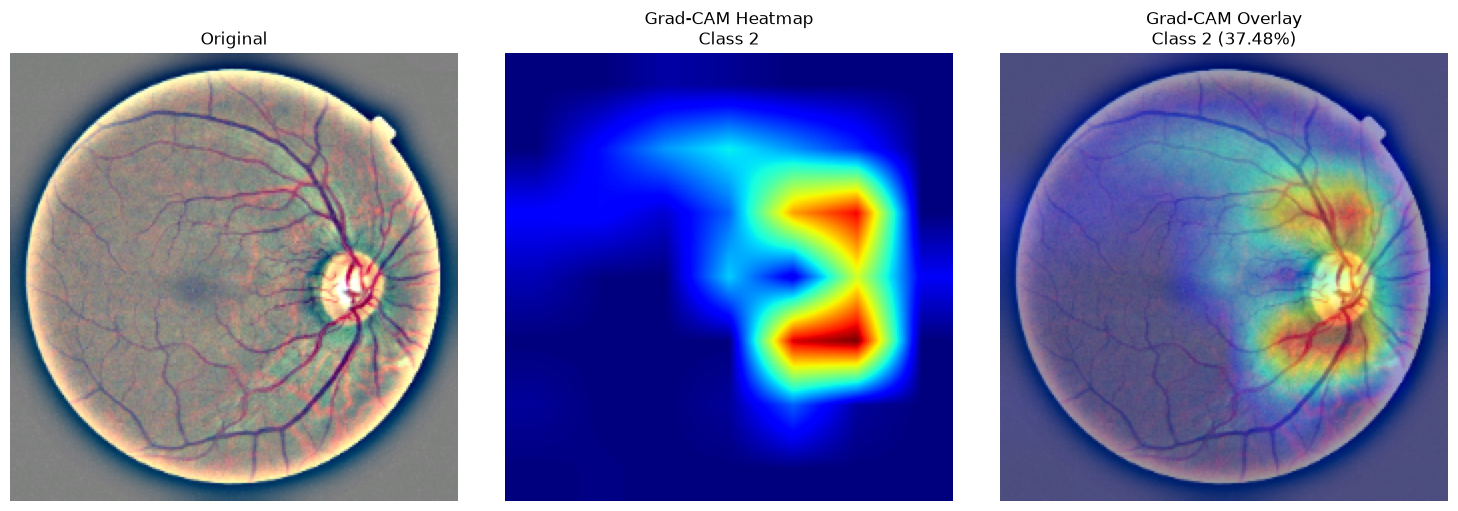

Saved: d:\Practice Projects\Disease Detection\reports\gradcam\gradcam\confidence_analysis\lowest_confidence_gradcam.png

STEP 27 COMPLETED SUCCESSFULLY
Highest confidence Grad-CAM: d:\Practice Projects\Disease Detection\reports\gradcam\gradcam\confidence_analysis\highest_confidence_gradcam.png
Lowest confidence Grad-CAM: d:\Practice Projects\Disease Detection\reports\gradcam\gradcam\confidence_analysis\lowest_confidence_gradcam.png


In [42]:
# STEP 27 — Save Grad-CAM for Highest and Lowest Confidence Images

from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd

# Output directory
CONF_GRADCAM_DIR = REPORT_DIR / "gradcam" / "confidence_analysis"
CONF_GRADCAM_DIR.mkdir(parents=True, exist_ok=True)


# =========================================================
# Function: Create and Save Grad-CAM Overlay
# =========================================================

def create_gradcam_overlay(image_path, class_index, confidence, filename):

    # Load original image
    img = cv2.imread(str(image_path))

    if img is None:
        print(f"ERROR: Could not load image: {image_path}")
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize image
    display_img = cv2.resize(img, (224, 224))

    # Prepare model input
    image = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    image_array = tf.keras.utils.img_to_array(image)

    input_tensor = np.expand_dims(
        image_array,
        axis=0
    )

    # Generate Grad-CAM
    heatmap = make_gradcam_heatmap(
        input_tensor,
        class_index
    )

    # Resize heatmap
    heatmap_resized = cv2.resize(
        heatmap,
        (224, 224)
    )

    # Convert heatmap to uint8
    heatmap_uint8 = np.uint8(
        255 * heatmap_resized
    )

    # Apply color map
    heatmap_color = cv2.applyColorMap(
        heatmap_uint8,
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    # Create overlay
    overlay = cv2.addWeighted(
        display_img,
        0.6,
        heatmap_color,
        0.4,
        0
    )

    # Create figure
    plt.figure(figsize=(15, 5))

    # Original
    plt.subplot(1, 3, 1)
    plt.imshow(display_img)
    plt.title("Original")
    plt.axis("off")

    # Heatmap
    plt.subplot(1, 3, 2)
    plt.imshow(
        heatmap_resized,
        cmap="jet"
    )
    plt.title(
        f"Grad-CAM Heatmap\nClass {class_index}"
    )
    plt.axis("off")

    # Overlay
    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(
        f"Grad-CAM Overlay\n"
        f"Class {class_index} ({confidence:.2%})"
    )
    plt.axis("off")

    plt.tight_layout()

    # Save
    save_path = CONF_GRADCAM_DIR / filename

    plt.savefig(
        save_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print(f"Saved: {save_path}")


# =========================================================
# Convert results to DataFrame
# =========================================================

results = pd.DataFrame(results)

print(f"Total results available: {len(results)}")


# =========================================================
# Find Highest and Lowest Confidence Images
# =========================================================

highest_row = results.loc[
    results["confidence"].idxmax()
]

lowest_row = results.loc[
    results["confidence"].idxmin()
]


# =========================================================
# Display Confidence Information
# =========================================================

print("\n========================================")
print("Highest Confidence")
print("========================================")

print("Image:", highest_row["image_path"])
print(
    "Predicted Class:",
    f"Class {int(highest_row['predicted_class'])}"
)
print(
    "Confidence:",
    f"{float(highest_row['confidence']) * 100:.2f}%"
)


print("\n========================================")
print("Lowest Confidence")
print("========================================")

print("Image:", lowest_row["image_path"])
print(
    "Predicted Class:",
    f"Class {int(lowest_row['predicted_class'])}"
)
print(
    "Confidence:",
    f"{float(lowest_row['confidence']) * 100:.2f}%"
)


# =========================================================
# Generate Grad-CAM — Highest Confidence
# =========================================================

highest_path = Path(
    highest_row["image_path"]
)

highest_class = int(
    highest_row["predicted_class"]
)

highest_conf = float(
    highest_row["confidence"]
)

print("\nGenerating Highest Confidence Grad-CAM...")

create_gradcam_overlay(
    highest_path,
    highest_class,
    highest_conf,
    "highest_confidence_gradcam.png"
)


# =========================================================
# Generate Grad-CAM — Lowest Confidence
# =========================================================

lowest_path = Path(
    lowest_row["image_path"]
)

lowest_class = int(
    lowest_row["predicted_class"]
)

lowest_conf = float(
    lowest_row["confidence"]
)

print("\nGenerating Lowest Confidence Grad-CAM...")

create_gradcam_overlay(
    lowest_path,
    lowest_class,
    lowest_conf,
    "lowest_confidence_gradcam.png"
)


# =========================================================
# Final Output
# =========================================================

print("\n========================================")
print("STEP 27 COMPLETED SUCCESSFULLY")
print("========================================")

print(
    "Highest confidence Grad-CAM:",
    CONF_GRADCAM_DIR / "highest_confidence_gradcam.png"
)

print(
    "Lowest confidence Grad-CAM:",
    CONF_GRADCAM_DIR / "lowest_confidence_gradcam.png"
)

In [43]:
# STEP 28 — Final Grad-CAM Summary

print("=" * 60)
print("GRAD-CAM ANALYSIS COMPLETED")
print("=" * 60)

print("\nGenerated Grad-CAM Results:")

print("\n1. Single Image Grad-CAM:")
print(
    REPORT_DIR /
    "gradcam" /
    "gradcam_20051020_43808_0100_PP.png"
)

print("\n2. Multiple Image Grad-CAM Results:")
print(
    REPORT_DIR /
    "gradcam" /
    "gradcam_multiple_image_results.csv"
)

print("\n3. Highest Confidence Grad-CAM:")
print(
    REPORT_DIR /
    "gradcam" /
    "confidence_analysis" /
    "highest_confidence_gradcam.png"
)

print("\n4. Lowest Confidence Grad-CAM:")
print(
    REPORT_DIR /
    "gradcam" /
    "confidence_analysis" /
    "lowest_confidence_gradcam.png"
)

GRAD-CAM ANALYSIS COMPLETED

Generated Grad-CAM Results:

1. Single Image Grad-CAM:
d:\Practice Projects\Disease Detection\reports\gradcam\gradcam\gradcam_20051020_43808_0100_PP.png

2. Multiple Image Grad-CAM Results:
d:\Practice Projects\Disease Detection\reports\gradcam\gradcam\gradcam_multiple_image_results.csv

3. Highest Confidence Grad-CAM:
d:\Practice Projects\Disease Detection\reports\gradcam\gradcam\confidence_analysis\highest_confidence_gradcam.png

4. Lowest Confidence Grad-CAM:
d:\Practice Projects\Disease Detection\reports\gradcam\gradcam\confidence_analysis\lowest_confidence_gradcam.png


In [38]:
%pip install opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/44.0 MB 1.1 MB/s eta 0:00:39
    --------------------------------------- 0.8/44.0 MB 1.1 MB/s eta 0:00:39
    --------------------------------------- 1.0/44.0 MB 1.2 MB/s eta 0:00:37
   - -------------------------------------- 1.3/44.0 MB 1.2 MB/s eta 0:00:35
   - -------------------------------------- 1.8/44.0 MB 1.4 MB/s eta 0:00:30
   -- ------------------------------------- 2.4/44.0 MB 1.6 MB/s eta 0:00:27
   -- ------------------------------------- 2.9/44.0 MB 1.6 MB/s eta 0:00:26
   -- ------------------------------------- 3.1/44.0 MB 1.7 MB/s eta 0:00:25
   --- ------------------------------------ 3.7/44.0 MB 1.7 MB/s eta 0:00:24
   --- ------------------------------------ 4.2/44.0 MB 1.7 MB/s eta 0:00:23
   ---- ------------